# Tonotopic Mapping via Per-Channel Evoked Responses

For each ECoG channel and each acoustic stimulus frequency, compute the mean
evoked response amplitude (RMS over the stimulation window). The **best
frequency (BF)** of a channel is the stimulus that elicits the largest
response. Plotting BF across channels reveals a tonotopic gradient.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from temporaldata import Data

from auditorydecoding.windowing import extract_windows

In [14]:
DATA_ROOT = "../data/processed/neurosoft_minipigs_2026"
RECORDING_ID = "sub-07_ses-03_task-AcousStim_acq-LH_desc-raw"
WINDOW_LENGTH = 0.5  # seconds (matches the 0.5 s stimulation period)

## Load data

In [15]:
path = os.path.join(DATA_ROOT, RECORDING_ID + ".h5")

with h5py.File(path) as f:
    data = Data.from_hdf5(f, lazy=False)

keep = data.channels.type == "ecog"
channel_names = data.channels.id[keep]
signal = data.ecog.signal[:, keep]
timestamps = np.asarray(data.ecog.timestamps)

print(f"Signal shape: {signal.shape}  ({signal.shape[1]} ECoG channels)")
print(f"Channel names: {channel_names}")

Signal shape: (1481380, 18)  (18 ECoG channels)
Channel names: ['SG2D1E12' 'SG2D1E1' 'SG2D1E8' 'SG2D1E15' 'SG2D1E5' 'SG2D1E2' 'SG2D1E16'
 'SG2D1E9' 'SG2D1E13' 'SG2D1E10' 'SG2D1E6' 'SG2D1E17' 'SG2D1E3' 'SG2D1E14'
 'SG2D1E18' 'SG2D1E4' 'SG2D1E7' 'SG2D1E11']


## Extract trial windows grouped by stimulus frequency

We use all acoustic stimulation trials (train + valid combined) since
we are computing descriptive statistics, not training a model.

In [16]:
intervals = data.acoustic_stim_trials

X_windows, y_labels = extract_windows(
    signal, timestamps, intervals, WINDOW_LENGTH
)

print(f"Windows: {X_windows.shape}  (trials, timepoints, channels)")
print(f"Unique labels: {np.unique(y_labels)}")

Extracting windows:   2%|▏         | 16/738 [00:00<00:04, 155.48it/s]

Extracting windows: 100%|██████████| 738/738 [00:04<00:00, 152.00it/s]
Skipping 0.1900 seconds of data due to short intervals. Remaining: 368.5 seconds.


Windows: (737, 1000, 18)  (trials, timepoints, channels)
Unique labels: ['stim_10000Hz' 'stim_1000Hz' 'stim_2000Hz' 'stim_5000Hz' 'stim_500Hz'
 'stim_8000Hz' 'stim_800Hz' 'stim_wn']


## Build the tuning matrix

For each (channel, stimulus frequency) pair, compute the mean RMS amplitude
across all trials of that frequency. The result is a matrix of shape
`(n_channels, n_frequencies)`.

In [17]:
unique_labels = np.unique(y_labels)
n_channels = X_windows.shape[2]
n_frequencies = len(unique_labels)

tuning_matrix = np.zeros((n_channels, n_frequencies))
trial_counts = np.zeros(n_frequencies, dtype=int)

for freq_idx, label in enumerate(unique_labels):
    mask = y_labels == label
    trials = X_windows[mask]  # (n_trials, n_timepoints, n_channels)
    trial_counts[freq_idx] = trials.shape[0]
    rms_per_trial = np.sqrt(np.mean(trials ** 2, axis=1))  # (n_trials, n_channels)
    tuning_matrix[:, freq_idx] = rms_per_trial.mean(axis=0)

print("Trials per frequency:")
for label, count in zip(unique_labels, trial_counts):
    print(f"  {label}: {count}")

Trials per frequency:
  stim_10000Hz: 92
  stim_1000Hz: 91
  stim_2000Hz: 91
  stim_5000Hz: 93
  stim_500Hz: 105
  stim_8000Hz: 93
  stim_800Hz: 108
  stim_wn: 64


## Best frequency per channel

In [18]:
best_freq_idx = np.argmax(tuning_matrix, axis=1)
best_freq_labels = unique_labels[best_freq_idx]

for ch, (name, bf) in enumerate(zip(channel_names, best_freq_labels)):
    print(f"  {name:>10s}  ->  BF = {bf}")

    SG2D1E12  ->  BF = stim_10000Hz
     SG2D1E1  ->  BF = stim_10000Hz
     SG2D1E8  ->  BF = stim_10000Hz
    SG2D1E15  ->  BF = stim_10000Hz
     SG2D1E5  ->  BF = stim_wn
     SG2D1E2  ->  BF = stim_10000Hz
    SG2D1E16  ->  BF = stim_10000Hz
     SG2D1E9  ->  BF = stim_10000Hz
    SG2D1E13  ->  BF = stim_10000Hz
    SG2D1E10  ->  BF = stim_10000Hz
     SG2D1E6  ->  BF = stim_10000Hz
    SG2D1E17  ->  BF = stim_10000Hz
     SG2D1E3  ->  BF = stim_10000Hz
    SG2D1E14  ->  BF = stim_500Hz
    SG2D1E18  ->  BF = stim_10000Hz
     SG2D1E4  ->  BF = stim_10000Hz
     SG2D1E7  ->  BF = stim_10000Hz
    SG2D1E11  ->  BF = stim_5000Hz


## Tuning matrix heatmap

Rows = channels, columns = stimulus frequencies. Color = mean RMS response.

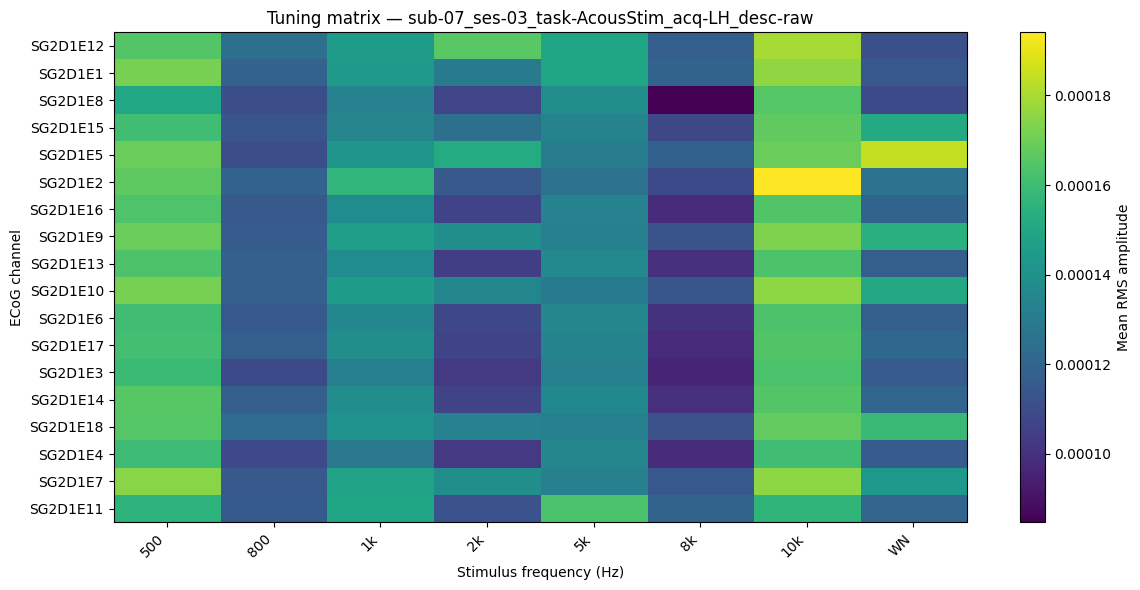

In [19]:
def _freq_sort_key(label: str) -> float:
    """Return numeric Hz value for sorting; white noise goes last."""
    if label == "stim_wn":
        return float("inf")
    hz_str = label.replace("stim_", "").replace("Hz", "")
    return float(hz_str)


sort_order = np.argsort([_freq_sort_key(l) for l in unique_labels])
sorted_labels = unique_labels[sort_order]
sorted_tuning = tuning_matrix[:, sort_order]


def _short_label(label: str) -> str:
    if label == "stim_wn":
        return "WN"
    hz = _freq_sort_key(label)
    if hz >= 1000:
        return f"{hz / 1000:.0f}k"
    return f"{hz:.0f}"


tick_labels = [_short_label(l) for l in sorted_labels]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(sorted_tuning, aspect="auto", interpolation="nearest")
ax.set_xticks(range(len(tick_labels)))
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
ax.set_xlabel("Stimulus frequency (Hz)")
ax.set_yticks(range(n_channels))
ax.set_yticklabels(channel_names)
ax.set_ylabel("ECoG channel")
ax.set_title(f"Tuning matrix — {RECORDING_ID}")
fig.colorbar(im, ax=ax, label="Mean RMS amplitude")
plt.tight_layout()
plt.show()

## Row-normalized tuning matrix

Normalizing each channel (row) to [0, 1] makes the frequency *preference*
visible even when channels have very different overall amplitudes.

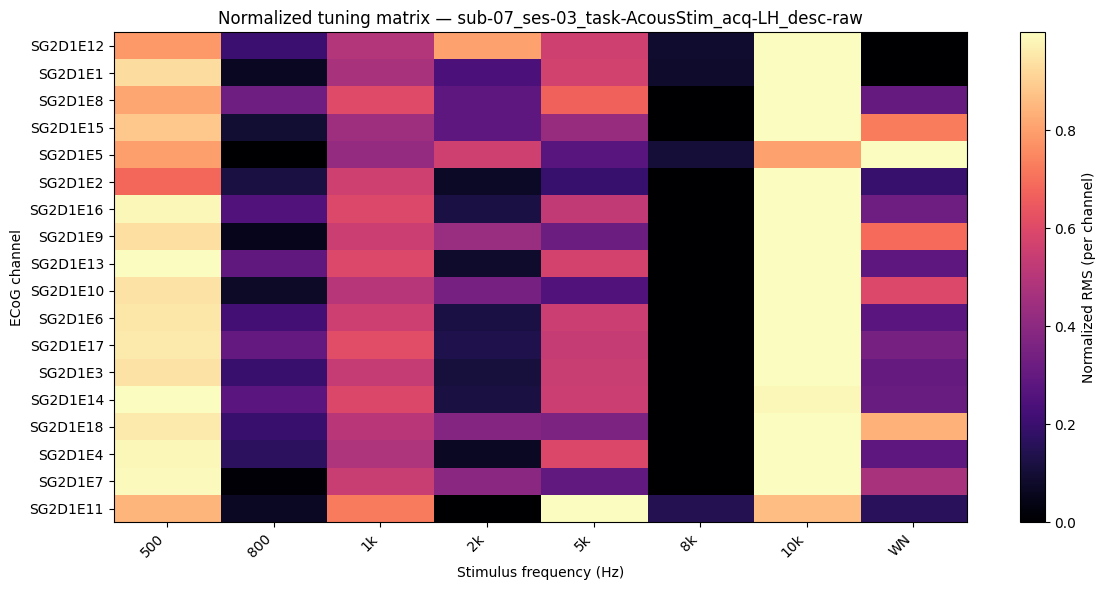

In [20]:
row_min = sorted_tuning.min(axis=1, keepdims=True)
row_max = sorted_tuning.max(axis=1, keepdims=True)
normed = (sorted_tuning - row_min) / (row_max - row_min + 1e-12)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(normed, aspect="auto", interpolation="nearest", cmap="magma")
ax.set_xticks(range(len(tick_labels)))
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
ax.set_xlabel("Stimulus frequency (Hz)")
ax.set_yticks(range(n_channels))
ax.set_yticklabels(channel_names)
ax.set_ylabel("ECoG channel")
ax.set_title(f"Normalized tuning matrix — {RECORDING_ID}")
fig.colorbar(im, ax=ax, label="Normalized RMS (per channel)")
plt.tight_layout()
plt.show()

## Per-channel tuning curves

Plot individual tuning curves (RMS vs stimulus frequency) for every channel,
overlaid in a single figure to compare selectivity.

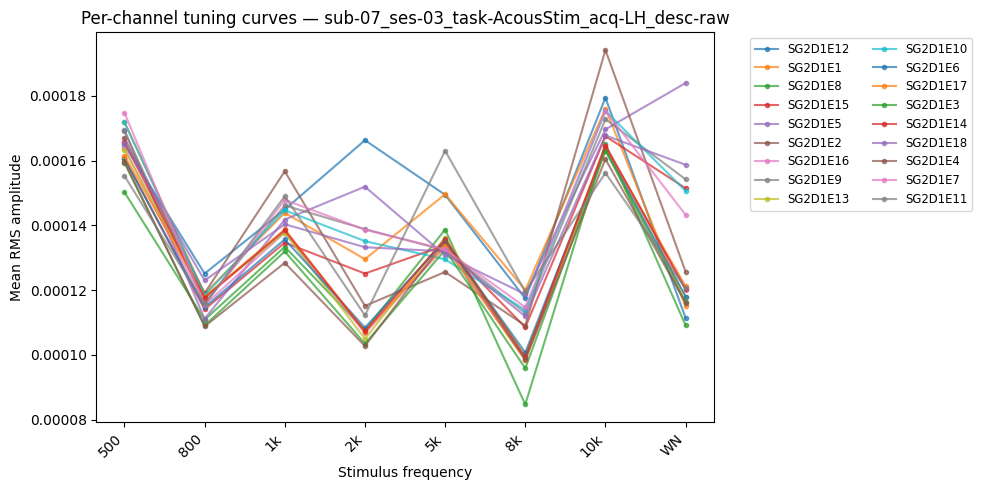

In [21]:
hz_values = np.array([_freq_sort_key(l) for l in sorted_labels])
# Replace inf (white noise) with a placeholder just past the highest tone
# for plotting on a log axis
max_tone_hz = hz_values[hz_values < float("inf")].max()
has_wn = np.isinf(hz_values).any()

fig, ax = plt.subplots(figsize=(10, 5))
for ch in range(n_channels):
    ax.plot(range(len(sorted_labels)), sorted_tuning[ch], marker="o", markersize=3,
            label=channel_names[ch], alpha=0.7)

ax.set_xticks(range(len(tick_labels)))
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
ax.set_xlabel("Stimulus frequency")
ax.set_ylabel("Mean RMS amplitude")
ax.set_title(f"Per-channel tuning curves — {RECORDING_ID}")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", ncol=2)
plt.tight_layout()
plt.show()

## Best-frequency strip map

Color each channel by its best frequency to visualize how BF varies
across the electrode array.

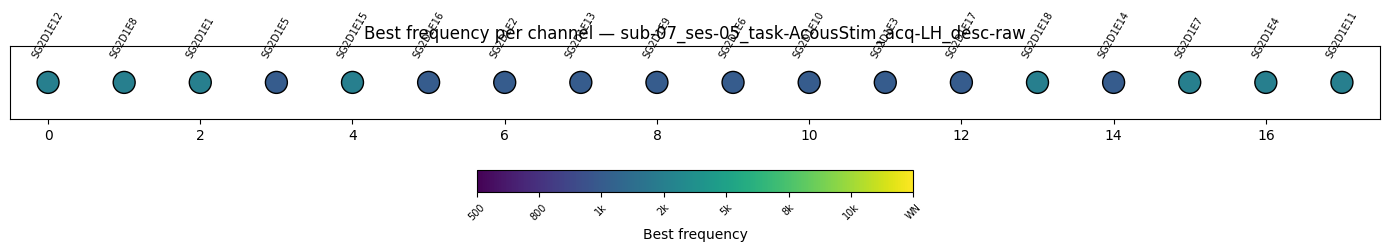

In [11]:
bf_sorted_idx = np.array([
    np.where(sort_order == idx)[0][0] for idx in best_freq_idx
])

fig, ax = plt.subplots(figsize=(14, 2.5))
scatter = ax.scatter(
    range(n_channels), np.zeros(n_channels),
    c=bf_sorted_idx, cmap="viridis",
    vmin=0, vmax=len(sorted_labels) - 1,
    s=250, edgecolors="k", zorder=3,
)
for ch in range(n_channels):
    ax.annotate(channel_names[ch], (ch, 0), textcoords="offset points",
                xytext=(0, 18), ha="center", fontsize=7, rotation=60)

cbar = fig.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.35,
                    ticks=range(len(sorted_labels)))
cbar.ax.set_xticklabels(tick_labels, fontsize=7, rotation=45)
cbar.set_label("Best frequency")

ax.set_yticks([])
ax.set_xlim(-0.5, n_channels - 0.5)
ax.set_title(f"Best frequency per channel — {RECORDING_ID}")
plt.tight_layout()
plt.show()

## Mean evoked traces per frequency (example channel)

Pick the channel with the highest overall selectivity (largest difference
between its best and worst frequency) and plot the average evoked trace
for each stimulus.

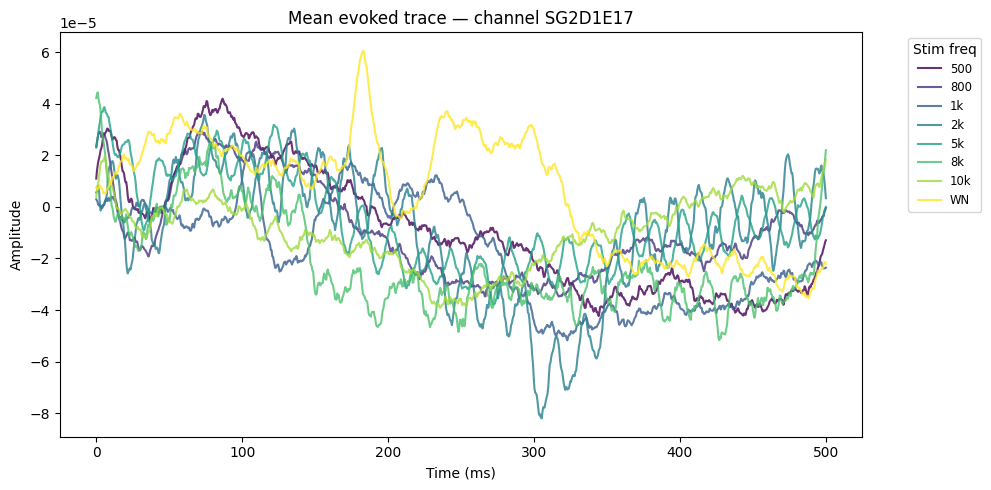

In [12]:
selectivity = sorted_tuning.max(axis=1) - sorted_tuning.min(axis=1)
most_selective_ch = int(np.argmax(selectivity))

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(sorted_labels)))

n_timepoints = X_windows.shape[1]
time_axis = np.linspace(0, WINDOW_LENGTH, n_timepoints) * 1000  # ms

for i, (freq_idx, label) in enumerate(zip(sort_order, sorted_labels)):
    mask = y_labels == unique_labels[freq_idx]
    traces = X_windows[mask, :, most_selective_ch]
    mean_trace = traces.mean(axis=0)
    ax.plot(time_axis, mean_trace, color=colors[i],
            label=_short_label(label), alpha=0.8)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Mean evoked trace — channel {channel_names[most_selective_ch]}")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small",
          title="Stim freq")
plt.tight_layout()
plt.show()

## Selectivity index per channel

A simple selectivity metric: `(max_RMS - min_RMS) / max_RMS` per channel.
Values near 1 indicate strong frequency preference; near 0 means the channel
responds equally to all frequencies.

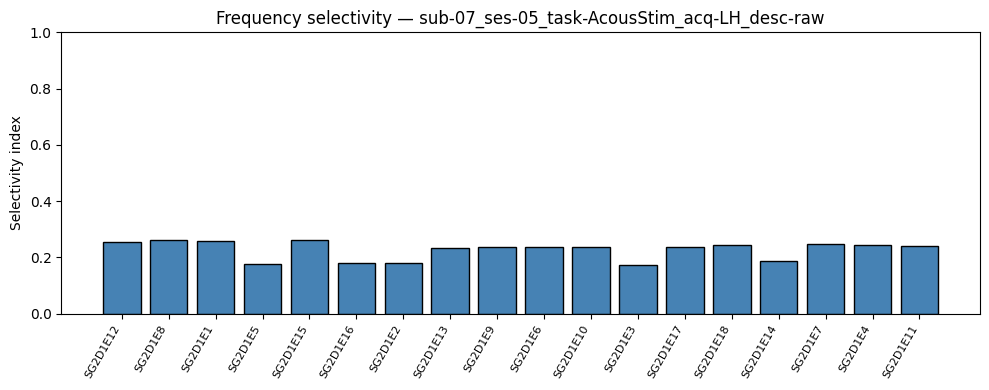

In [13]:
sel_index = (sorted_tuning.max(axis=1) - sorted_tuning.min(axis=1)) / (
    sorted_tuning.max(axis=1) + 1e-12
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(n_channels), sel_index, color="steelblue", edgecolor="k")
ax.set_xticks(range(n_channels))
ax.set_xticklabels(channel_names, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Selectivity index")
ax.set_title(f"Frequency selectivity — {RECORDING_ID}")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()